In [20]:
import numpy as np
import pandas as pd
import json
import gc
import re
import os

# -------------------------------------------------------------------
# Kaggle-specific file paths
# Replace <your-dataset-folder> with the folder name in /kaggle/input
# -------------------------------------------------------------------
DATA_PATH = "/kaggle/input/intelligent-bank/"

# Load CSV files
transaction_df = pd.read_csv(os.path.join(DATA_PATH, "transactions_data_south_africa.csv"))
card_df = pd.read_csv(os.path.join(DATA_PATH, "cards_data_south_africa.csv"))
users_df = pd.read_csv(os.path.join(DATA_PATH, "user_data_south_africa.csv"))

# Load MCC JSON file
mcc_series = pd.read_json(os.path.join(DATA_PATH, "mcc_codes.json"), typ='series')
mcc_df = mcc_series.reset_index()
mcc_df.columns = ['mcc_code', 'description']

# Load labels JSON
file_path = os.path.join(DATA_PATH, 'train_fraud_labels.json')

with open(file_path, 'r') as f:
    raw_json_data = json.load(f)

transaction_labels_dict = raw_json_data['target']

train_fraud_labels = pd.Series(transaction_labels_dict).reset_index()
train_fraud_labels.columns = ['transaction_id', 'is_fraud']
train_fraud_labels['transaction_id'] = pd.to_numeric(train_fraud_labels['transaction_id'])

print("\nAll data files loaded successfully in Kaggle environment.")



All data files loaded successfully in Kaggle environment.


## Transaction csv data

In [3]:
transaction_df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2022-02-19 05:51:55,1556,2972,-1386.00,Swipe Transaction,59935,Kimberley,Northern Cape,8300.0,5499.0,NaN
1,7475328,2023-01-13 02:58:58,561,4575,262.26,Swipe Transaction,67570,Pietermaritzburg,KwaZulu-Natal,3200.0,5311.0,NaN
2,7475329,2024-07-03 23:41:24,1129,102,1440.00,Swipe Transaction,27092,Port Elizabeth,Eastern Cape,6000.0,4829.0,NaN
3,7475331,2022-06-12 09:33:41,430,2860,3600.00,Swipe Transaction,27092,Bloemfontein,Free State,9300.0,4829.0,NaN
4,7475332,2023-08-26 10:05:48,848,3915,835.38,Swipe Transaction,13051,Polokwane,Limpopo,700.0,5813.0,NaN


In [3]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12858754 entries, 0 to 12858753
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          float64
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             float64
 11  errors          object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.1+ GB


In [56]:
transaction_df.describe()

,id,client_id,card_id,amount,merchant_id,zip,mcc
count,1.285875e+07,1.285875e+07,1.285875e+07,1.285875e+07,1.285875e+07,1.134923e+07,1.285875e+07
mean,1.530925e+07,1.026802e+03,3.475013e+03,7.739152e+02,4.772799e+04,4.017428e+03,5.565479e+03
std,4.544713e+06,5.816489e+02,1.674463e+03,1.471071e+03,2.581482e+04,3.176196e+03,8.755668e+02
min,7.475327e+06,0.000000e+00,0.000000e+00,-9.000000e+03,1.000000e+00,1.000000e+00,1.711000e+03
25%,1.136989e+07,5.190000e+02,2.413000e+03,1.607400e+02,2.588700e+04,1.200000e+03,5.300000e+03
50%,1.529639e+07,1.070000e+03,3.583000e+03,5.218200e+02,4.592800e+04,4.000000e+03,5.499000e+03
75%,1.924064e+07,1.530000e+03,4.905000e+03,1.147140e+03,6.757000e+04,8.000000e+03,5.812000e+03
max,2.320947e+07,1.998000e+03,6.138000e+03,1.227636e+05,1.003420e+05,9.300000e+03,9.402000e+03


In [57]:
transaction_df.duplicated()

0           False
1           False
2           False
3           False
4           False
            ...  
12858749    False
12858750    False
12858751    False
12858752    False
12858753    False
Length: 12858754, dtype: bool

In [58]:
transaction_df.duplicated().sum()

0

In [59]:
transaction_df.isnull()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,False,False,False,False,False,False,False,False,True,True,False,True
12858750,False,False,False,False,False,False,False,False,False,False,False,True
12858751,False,False,False,False,False,False,False,False,True,True,False,True
12858752,False,False,False,False,False,False,False,False,False,False,False,True


In [4]:
transaction_df.isnull().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1509523
zip                1509523
mcc                      1
errors            12654526
dtype: int64

In [21]:
# creating mapping from city to state and city to zip where is not null
city_state_map = transaction_df.dropna(subset=['merchant_state']).set_index('merchant_city')['merchant_state'].to_dict()
city_zip_map = transaction_df.dropna(subset=['zip']).set_index('merchant_city')['zip'].to_dict()

# fill missing merchant state using mapping

transaction_df['merchant_state'] = transaction_df.apply(
    lambda row: city_state_map.get(row['merchant_city'], row['merchant_state']),
    axis=1
)


transaction_df['zip'] = transaction_df.apply(
    lambda row: city_zip_map.get(row['merchant_city'], row['zip']),
    axis=1
)

# handle mccc missing value
transaction_df['mcc'] = pd.to_numeric(transaction_df['mcc'], errors='coerce')
mcc_mean = transaction_df['mcc'].mean()
transaction_df['mcc'] = transaction_df['mcc'].fillna(mcc_mean)
print("\nAfter filling missing values:\n", transaction_df)


After filling missing values:
                 id                 date  client_id  card_id   amount  \
0          7475327  2022-02-19 05:51:55       1556     2972 -1386.00   
1          7475328  2023-01-13 02:58:58        561     4575   262.26   
2          7475329  2024-07-03 23:41:24       1129      102  1440.00   
3          7475331  2022-06-12 09:33:41        430     2860  3600.00   
4          7475332  2023-08-26 10:05:48        848     3915   835.38   
...            ...                  ...        ...      ...      ...   
12858749  23209463  2022-05-16 02:17:24        597     4540   126.00   
12858750  23209464  2023-07-23 01:05:29       1508     3279   593.46   
12858751  23209465  2023-05-03 10:17:19       1727     4918   284.04   
12858752  23209466  2022-05-15 15:12:30        467     4278   812.88   
12858753  23209467  2022-04-17 21:21:33       1384     3723  1014.48   

                    use_chip  merchant_id     merchant_city merchant_state  \
0          Swipe Transact

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [29]:
transaction_df.isnull().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1509523
zip                1509523
mcc                      0
errors            12654526
dtype: int64

## Card csv data

In [7]:
card_df.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Mastercard,Debit,5561765976957072,04/2025,623,YES,2,437310,09/2002,2008,No
1,2731,825,Mastercard,Debit,5681404028657264,08/2025,393,YES,2,395424,04/2014,2014,No
2,3701,825,Visa,Debit,4715119191099084,08/2025,719,YES,2,835452,07/2003,2004,No
3,42,825,Visa,Credit,4133211808921544,12/2026,693,NO,1,223200,01/2003,2012,No
4,4659,825,Mastercard,Prepaid,5469974597438641,10/2026,75,YES,1,504,09/2008,2009,No


In [60]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   int64 
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(7), object(6)
memory usage: 624.3+ KB


In [61]:
card_df.describe()

,id,client_id,card_number,cvv,num_cards_issued,credit_limit,year_pin_last_changed
count,6146.000000,6146.000000,6.146000e+03,6146.000000,6146.000000,6.146000e+03,6146.000000
mean,3072.500000,994.939636,4.710118e+15,506.220794,1.503091,2.582549e+05,2013.436707
std,1774.341709,578.614626,1.383261e+15,289.431123,0.519191,2.162603e+05,4.270699
min,0.000000,0.000000,3.002159e+14,0.000000,1.000000,0.000000e+00,2002.000000
25%,1536.250000,492.250000,4.401621e+15,257.000000,1.000000,1.267695e+05,2010.000000
50%,3072.500000,992.000000,4.937990e+15,516.500000,1.000000,2.266650e+05,2013.000000
75%,4608.750000,1495.000000,5.514460e+15,756.000000,2.000000,3.448170e+05,2017.000000
max,6145.000000,1999.000000,6.986868e+15,999.000000,3.000000,2.722014e+06,2020.000000


In [62]:
card_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6141    False
6142    False
6143    False
6144    False
6145    False
Length: 6146, dtype: bool

In [63]:
card_df.duplicated().sum()

0

In [64]:
card_df.isnull()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,False,False,False,False,False,False,False,False,False,False,False,False,False
6142,False,False,False,False,False,False,False,False,False,False,False,False,False
6143,False,False,False,False,False,False,False,False,False,False,False,False,False
6144,False,False,False,False,False,False,False,False,False,False,False,False,False


In [65]:
card_df.isnull().sum()

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

## User csv data

In [9]:
users_df.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,"126 Main Road, Durban",527004,1074528,2297034,787,5
1,1746,53,68,1966,12,Female,"254 Van der Merwe Avenue, Cape Town",682038,1390572,3444282,701,5
2,1718,81,67,1938,11,Female,"856 King George Street, Pietermaritzburg",408258,602694,3528,698,5
3,708,63,63,1957,1,Female,"565 Pretoria Street, Durban",2936610,4498650,3641904,722,4
4,1164,43,70,1976,9,Male,"269 Swart Street, Pretoria",968346,1974366,3309390,675,1


In [10]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   int64 
 1   current_age        2000 non-null   int64 
 2   retirement_age     2000 non-null   int64 
 3   birth_year         2000 non-null   int64 
 4   birth_month        2000 non-null   int64 
 5   gender             2000 non-null   object
 6   address            2000 non-null   object
 7   per_capita_income  2000 non-null   int64 
 8   yearly_income      2000 non-null   int64 
 9   total_debt         2000 non-null   int64 
 10  credit_score       2000 non-null   int64 
 11  num_credit_cards   2000 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 187.6+ KB


In [66]:
users_df.describe()

,id,current_age,retirement_age,birth_year,birth_month,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2000.000000
mean,999.500000,45.391500,66.237500,1973.803000,6.439000,4.165547e+05,8.228859e+05,1.146774e+06,709.734500,3.073000
std,577.494589,18.414092,3.628867,18.421234,3.565338,2.038345e+05,4.138671e+05,9.405802e+05,67.221949,1.637379
min,0.000000,18.000000,50.000000,1918.000000,1.000000,0.000000e+00,1.800000e+01,0.000000e+00,480.000000,1.000000
25%,499.750000,30.000000,65.000000,1961.000000,3.000000,3.028410e+05,5.907330e+05,4.317615e+05,681.000000,2.000000
50%,999.500000,44.000000,66.000000,1975.000000,7.000000,3.704580e+05,7.334010e+05,1.048518e+06,711.500000,3.000000
75%,1499.250000,58.000000,68.000000,1989.000000,10.000000,4.731480e+05,9.485730e+05,1.603269e+06,753.000000,4.000000
max,1999.000000,101.000000,79.000000,2002.000000,12.000000,2.936610e+06,5.526324e+06,9.292734e+06,850.000000,9.000000


In [67]:
users_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

In [68]:
users_df.duplicated().sum()

0

In [69]:
users_df.isnull()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False,False,False,False


In [70]:
users_df.isnull().sum()

id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

### JSON file

In [11]:
mcc_df.head()

,mcc_code,description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


In [12]:
mcc_df.duplicated().sum()

0

In [ ]:
mcc_df.isnull().sum().mean()*100

In [28]:
train_fraud_labels.head()

,transaction_id,is_fraud
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


In [14]:
train_fraud_labels.isnull().sum()

transaction_id    0
is_fraud          0
dtype: int64

In [ ]:
# Save to Kaggle working directory
output_path = "/kaggle/working/train_fraud_labels.csv"
train_fraud_labels.to_csv(output_path, index=False)

print(f"File saved successfully at: {output_path}")

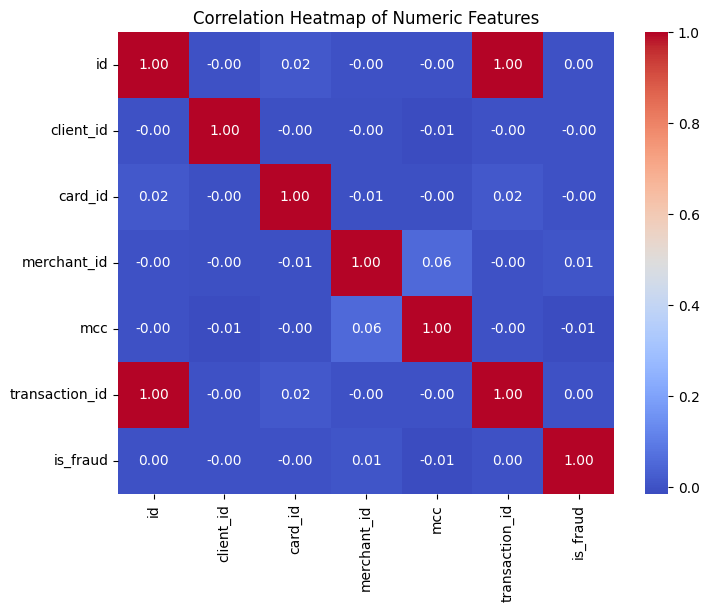

In [71]:

# Correlation Heatmap

# Select numeric columns for correlation
numeric_cols = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()



In [72]:
# Distribution of Transaction Amount
import plotly.express as px

fig_amount = px.histogram(data, x='amount', nbins=50, title='Distribution of Transaction Amount')
fig_amount.show()


ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['id', 'date', 'client_id', 'card_id', 'merchant_id', 'mcc', 'transaction_id', 'is_fraud'] but received: amount

In [73]:
# Fix MCC frequency plot
mcc_counts = data['mcc'].value_counts().reset_index()
mcc_counts.columns = ['MCC Code', 'Count']

# Show top 10 MCC codes
top_mcc = mcc_counts.head(10)

import plotly.express as px
fig_mcc = px.bar(top_mcc, x='MCC Code', y='Count', title='Top 10 MCC Codes by Frequency')
fig_mcc.show()


In [74]:
# Plot all MCC codes sorted by frequency
import plotly.express as px
fig_mcc = px.bar(
    mcc_counts,
    x='MCC Code',
    y='Count',
    title='Frequency of All MCC Codes',
    labels={'MCC Code': 'MCC Code', 'Count': 'Transaction Count'}
)
fig_mcc.update_xaxes(type='category')  # Treat MCC codes as categories
fig_mcc.show()


### Scatter Plot

In [75]:
# Scatter Plot (Amount vs MCC)
fig_scatter = px.scatter(data, x='mcc', y='amount', color='is_fraud',
                         title='Scatter Plot: MCC vs Transaction Amount')
fig_scatter.show()


ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['id', 'date', 'client_id', 'card_id', 'merchant_id', 'mcc', 'transaction_id', 'is_fraud'] but received: amount

In [76]:
# Box Plot for Whiskers & Outliers (Amount)
fig_box = px.box(data, y='amount', color='is_fraud',
                 title='Box Plot of Transaction Amount by Fraud Status')
fig_box.show()


ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['id', 'date', 'client_id', 'card_id', 'merchant_id', 'mcc', 'transaction_id', 'is_fraud'] but received: amount

## Final ML Pipeline with Gradient Boosting

### 1. Load and preprocess labels

In [30]:
# preprocess labels
train_fraud_labels['is_fraud'] = train_fraud_labels['is_fraud'].map({'Yes': 1, 'No': 0})
train_fraud_labels.head()

,transaction_id,is_fraud
0,10649266,0
1,23410063,0
2,9316588,0
3,12478022,0
4,9558530,0


In [31]:
transaction_df.head()


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2022-02-19 05:51:55,1556,2972,-1386.00,Swipe Transaction,59935,Kimberley,Northern Cape,8300.0,5499.0,NaN
1,7475328,2023-01-13 02:58:58,561,4575,262.26,Swipe Transaction,67570,Pietermaritzburg,KwaZulu-Natal,3200.0,5311.0,NaN
2,7475329,2024-07-03 23:41:24,1129,102,1440.00,Swipe Transaction,27092,Port Elizabeth,Eastern Cape,6000.0,4829.0,NaN
3,7475331,2022-06-12 09:33:41,430,2860,3600.00,Swipe Transaction,27092,Bloemfontein,Free State,9300.0,4829.0,NaN
4,7475332,2023-08-26 10:05:48,848,3915,835.38,Swipe Transaction,13051,Polokwane,Limpopo,700.0,5813.0,NaN


### 2. Merge with transaction

In [32]:
# Merge train_fraud_labels with transactions
data = transaction_df.merge(train_fraud_labels, left_on='id', right_on='transaction_id', how='inner')
drop_cols = ['amount', 'zip', 'merchant_state', 'merchant_city', 'use_chip', 'errors']
data.drop(columns=drop_cols, inplace=True)

In [34]:
data.head()

,id,date,client_id,card_id,merchant_id,mcc,transaction_id,is_fraud
0,7475327,2022-02-19 05:51:55,1556,2972,59935,5499.0,7475327,0
1,7475328,2023-01-13 02:58:58,561,4575,67570,5311.0,7475328,0
2,7475329,2024-07-03 23:41:24,1129,102,27092,4829.0,7475329,0
3,7475332,2023-08-26 10:05:48,848,3915,13051,5813.0,7475332,0
4,7475333,2022-05-17 22:31:08,1807,165,20519,5942.0,7475333,0


### 3. Encode categorical features

In [35]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['card_id', 'merchant_id', 'mcc']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

### 4. Split features and target

In [36]:
# Split features and target
from sklearn.model_selection import train_test_split

X = data.drop(['is_fraud', 'id', 'date', 'client_id'], axis=1)
y = data['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 5. Build pipeline (XGBoost)

The simplest and most recommended method.

## Using scale_pos_weight

XGBoost boosts the importance of fraud cases during training.

How to calculate it:
scale_pos_weight = (number of non-fraud cases) / (number of fraud cases)

In [77]:
from xgboost import XGBClassifier

# Calculate imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos


In [79]:
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # handle imbalance
    random_state=42
)

### 6. Train

In [80]:
from sklearn.model_selection import train_test_split
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### 7. Evaluate

In [81]:
# Evaluate
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, auc, accuracy_score, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1720544
           1       0.01      0.92      0.03      2563

    accuracy                           0.91   1723107
   macro avg       0.51      0.91      0.49   1723107
weighted avg       1.00      0.91      0.95   1723107

ROC AUC: 0.9695982768583619


In [82]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

Overall Accuracy: 0.9057

--- Detailed Classification Report ---
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95   1720544
       Fraud       0.01      0.92      0.03      2563

    accuracy                           0.91   1723107
   macro avg       0.51      0.91      0.49   1723107
weighted avg       1.00      0.91      0.95   1723107



- Class 0 = Non-fraud transactions
- Class 1 = Fraud transactions

### Metrics:

- Precision: Of all predicted frauds, how many were correct?

        - For fraud (class 1): 0.01 → Very low (lots of false positives).


- Recall: Of all actual frauds, how many did we catch?

        - For fraud: 0.92 → Excellent (we catch most fraud cases).


- F1-score: Balance between precision and recall.

        - For fraud: 0.02 → Very low because precision is poor.


- Support: Number of samples in each class.

        - Fraud cases are extremely rare (2563 vs 1.7M non-fraud).



- Accuracy: 0.88 → Looks good, but misleading because of imbalance.

- Macro avg: Average across classes (treats both equally).

- Weighted avg: Weighted by class size (dominated by non-fraud).

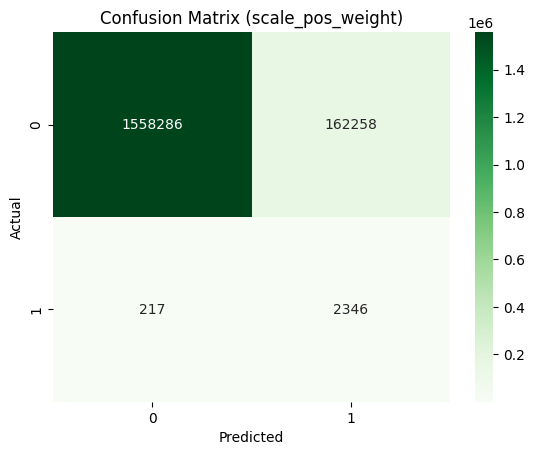

In [83]:
import seaborn as sns, matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (scale_pos_weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

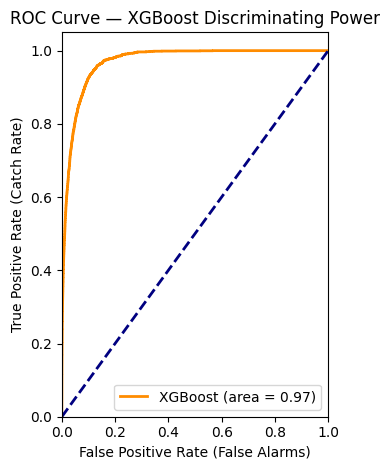

In [85]:
# This curve shows the trade-off between catching fraud and false alarms
y_probs = model.predict_proba(X_test)[:, 1] # Get probabilities for the 'Fraud' class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
 
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Catch Rate)')
plt.title('ROC Curve — XGBoost Discriminating Power')
plt.legend(loc="lower right")
 
plt.tight_layout()
plt.show()

- Class 1 (Fraud) precision is **~0.01** with very high recall (**~0.92**).
- That means the model is flagging way too many transactions as fraud (many false positives).
- The ROC AUC is strong (**0.964**), so the model can separate classes; the problem is the **decision threshold** and **class imbalance handling**.

# A strong, pragmatic XGB setup

In [43]:
model = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    learning_rate=0.04,
    n_estimators=2000,          # early stopping will select best round
    max_depth=6,
    min_child_weight=5,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg / max(pos, 1),
    eval_metric="aucpr",
    random_state=42,
    n_jobs=8
)


In [46]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=100,
    verbose=False
)

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=8,
              num_parallel_tree=None, random_state=42, ...)

In [47]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1720544
           1       0.02      0.90      0.03      2563

    accuracy                           0.92   1723107
   macro avg       0.51      0.91      0.50   1723107
weighted avg       1.00      0.92      0.96   1723107

ROC AUC: 0.9726489555742757


# Tune XGBoost-Hyperparameter

## 1. Split out an internal validation set (for threshold tuning)

In [48]:
# Assuming you already have X_train, y_train, X_test, y_test
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [49]:
# Class imbalance ratio for scale_pos_weight (pos=1)
neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
spw = neg / max(pos, 1)  # safe guard
print(f"neg={neg}, pos={pos}, scale_pos_weight={spw:.2f}")


neg=5505738, pos=8202, scale_pos_weight=671.27


## 2. Train a stronger baseline XGBoost with early stopping (AUC-PR focus)

- Use eval_metric="aucpr" (better for imbalanced data than ROC AUC).
- Add regularization and child-weight to reduce noisy splits.
- Use early stopping to pick the best number of trees.

In [50]:
xgb = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",           # fast & robust; if GPU available: "gpu_hist"
    n_estimators=2000,            # large; early stopping will pick best_iter
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,           # reduce overfitting / spurious leaves
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,               # L2 regularization
    reg_alpha=0.0,                # L1; try >0 if still overfitting
    scale_pos_weight=spw,         # imbalance handling
    random_state=42
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="aucpr",
    early_stopping_rounds=100,
    verbose=False
)

print("Best n_estimators (early-stopped):", xgb.best_iteration + 1)

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Best n_estimators (early-stopped): 1998


In [52]:
y_pred = xgb.predict(X_val)
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1376435
           1       0.02      0.89      0.03      2051

    accuracy                           0.92   1378486
   macro avg       0.51      0.90      0.49   1378486
weighted avg       1.00      0.92      0.95   1378486

ROC AUC: 0.990032921574652


## 3. Threshold tuning to improve Fraud precision and F1

Find:

- thresh_f1: threshold that maximizes F1 for class 1 on the validation set.
- thresh_pXX: threshold that achieves at least a target precision (e.g., 50% or 80%), choose based on business tolerance for false alarms.

In [53]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, f1_score, average_precision_score

# Get calibrated scores for the positive class (label 1)
pos_idx = list(xgb.classes_).index(1)
val_scores = xgb.predict_proba(X_val)[:, pos_idx]

# Precision–Recall curve and F1 across thresholds
prec, rec, thr = precision_recall_curve(y_val, val_scores)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)
thresh_f1 = thr[best_idx] if best_idx < len(thr) else 0.5

# Optionally enforce a minimum precision target (e.g., ≥ 0.50 or ≥ 0.80)
target_precision = 0.50
candidates = np.where(prec[:-1] >= target_precision)[0]  # exclude last point (no threshold)
thresh_p50 = thr[candidates[0]] if len(candidates) else thresh_f1  # first threshold meeting precision

print(f"Validation Average Precision (AUC-PR): {average_precision_score(y_val, val_scores):.4f}")
print(f"Best F1 threshold on val: {thresh_f1:.4f} | F1={f1[best_idx]:.4f}, P={prec[best_idx]:.4f}, R={rec[best_idx]:.4f}")
print(f"Precision≥{target_precision:.0%} threshold on val: {thresh_p50:.4f}")


Validation Average Precision (AUC-PR): 0.1272
Best F1 threshold on val: 0.9557 | F1=0.2118, P=0.1959, R=0.2306
Precision≥50% threshold on val: 0.9937


In [55]:
y_pred = xgb.predict(X_val)
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1376435
           1       0.02      0.89      0.03      2051

    accuracy                           0.92   1378486
   macro avg       0.51      0.90      0.49   1378486
weighted avg       1.00      0.92      0.95   1378486

ROC AUC: 0.9677522796000055


In [ ]:
def evaluate_at_threshold(model, X, y, threshold):
    pos_idx = list(model.classes_).index(1)
    scores = model.predict_proba(X)[:, pos_idx]
    y_pred = (scores >= threshold).astype(int)
    print(f"\n=== Evaluation at threshold={threshold:.4f} ===")
    print(classification_report(y, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))
    return y_pred

# Compare thresholds on test data
y_pred_f1 = evaluate_at_threshold(xgb, X_test, y_test, thresh_f1)
y_pred_p50 = evaluate_at_threshold(xgb, X_test, y_test, thresh_p50)


# Interpretation:

The results show very high recall but extremely low precision for fraud. Raising the threshold will reduce false positives (increase precision) and typically lower recall. The F1-max threshold balances the two; the precision-target threshold enforces fewer false alarms.

# Confusion Matrix Heatmap + ROC Curve

In [ ]:
def plot_cm_and_roc(
    model,
    X_test,
    y_test,
    threshold: float = 0.50,
    class_names=('0: Non-fraud', '1: Fraud'),
    save_path: str = None
):
    """
    Plot confusion matrix heatmap and ROC curve side-by-side for a binary classifier.
    Also prints classification report and ROC AUC.

    Parameters
    ----------
    model : fitted classifier or Pipeline with predict_proba
    X_test, y_test : test set
    threshold : float
        Probability threshold for predicting the positive class (fraud).
    class_names : tuple[str, str]
        Names to display for classes in the confusion matrix (order: [0, 1]).
    save_path : str or None
        If provided, saves the figure to this path (e.g., 'model_eval.png').
    """
    # ---- 1) Scores and predictions (ensure we use the positive class column) ----
    # Most sklearn/xgboost models expose .classes_
    if hasattr(model, "classes_"):
        if 1 in model.classes_:
            pos_idx = list(model.classes_).index(1)   # positive class = 1
        else:
            # Fallback: assume second column is positive class
            pos_idx = 1
    else:
        pos_idx = 1

    y_scores = model.predict_proba(X_test)[:, pos_idx]   # probabilities for class 1 (Fraud)
    y_pred = (y_scores >= threshold).astype(int)

    # ---- 2) Confusion Matrix & Metrics ----
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    report = classification_report(
        y_test, y_pred, target_names=['Non-fraud', 'Fraud'], digits=4
    )
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)  # same as roc_auc_score(y_test, y_scores)

    print(report)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Using threshold = {threshold:.4f}")

    # ---- 3) Plotting ----
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    # (A) Confusion Matrix Heatmap
    ax0 = axes[0]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=[class_names[0], class_names[1]],
        yticklabels=[class_names[0], class_names[1]],
        ax=ax0
    )
    ax0.set_title('Confusion Matrix (Fraud Detection)')
    ax0.set_xlabel('Predicted Label')
    ax0.set_ylabel('True Label')

    # (B) ROC Curve
    ax1 = axes[1]
    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate (False Alarms)')
    ax1.set_ylabel('True Positive Rate (Catch Rate)')
    ax1.set_title('ROC Curve: Model Discriminating Power')
    ax1.legend(loc="lower right")

    plt.tight_layout()

    # Optional: save
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved figure → {save_path}")

    plt.show()


In [ ]:
# Example call (works with your XGBClassifier or Pipeline)
plot_cm_and_roc(
    model=xgb,          # or your `xgb` model
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,          # try a higher threshold (e.g., 0.80) to improve precision
    class_names=('0: Non-fraud', '1: Fraud'),
    save_path="model_eval.png"
)


In [ ]:
plt.savefig("ROC_Curve.png", dpi=300, bbox_inches='tight')

## Using SMOTE (Synthetic Minority Oversampling Technique)

SMOTE creates synthetic fraud examples by interpolating between real fraud observations.

- The model is underfitting the minority class.
- We want more fraud samples without oversampling noise.

In [ ]:
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U",
                       "scikit-learn==1.4.2", "imbalanced-learn==0.12.3"])

import sklearn, imblearn
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)


In [ ]:
# Build pipeline
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)


pipeline = Pipeline([
    ('model', model)
])


# **Model Improvement**

## Feature Importance
- Identifies which variables influence fraud prediction the most
- Helps validate model logic and improve features
- Supports explainability for risk and audit teams

## Hyperparameter Tuning
- Adjusts model settings for better performance
- Improves precision, recall, and stability
- Prevents overfitting and boosts generalization

## Cross‑Validation
- Tests the model across multiple data splits
- Ensures stable, reliable, consistent performance
- Helps choose the best hyperparameter settings


# **Share Insights & Models With Developers**

- Package and export our XGBoost model + preprocessing pipeline
- Build a simple FastAPI prediction endpoint
- Provide developers with model files, API code, and documentation

# FastAPI

FastAPI is a Python framework that lets you turn your machine learning model into an API service so that developers can call it from the banking system.

Why FaStAPI
- Fast
- Easy to deploy
- Works smoothly with Python models (XGBoost, sklearn, etc.)
- Used in modern ML systems

## 1. Save trained model

In [ ]:
import joblib
joblib.dump(model, "xgb_fraud_model.pkl")
joblib.dump(pipeline, "preprocess.pkl")

## 2. Create a prediction function

- Load model
- Load preprocessing step
- Apply threshold
- Return fraud score + decision

## 3. Create a FastAPI prediction endpoint

In [ ]:
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("xgb_fraud_model.pkl")
pipeline = joblib.load("preprocess.pkl")
threshold = 0.5   # example threshold

@app.post("/predict")
def predict(transaction: dict):
    # Extract features
    data = pipeline.transform([transaction])
    prob = model.predict_proba(data)[0][1]
    label = int(prob >= threshold)

    return {
        "fraud_probability": float(prob),
        "fraud_flag": label
    }